# The faithful-methodology battery — gemma-4-31b-it (Q1.H2.E4)

The E1/E2 nulls were on a base model — a deviation from both the paper (RLHF'd assistant) and
the reference (instruct model). This is the corrected run: probes re-extracted from
gemma-4-31b-it on the story corpus (`results/emotion_vectors_it/`), battery activations
collected under BOTH plain `Human:/Assistant:` text and -it's own **chat template**
(`results/probe_sweep_it/`), all 20 layers x 3 readouts.

**Registered rule (unchanged from E2)**: select on the paper's 12 scenarios, count only if the
same (format, layer, readout) combination reaches target-in-top-3 >= 8/12 on the held-out 12.

**Context from the geometry check**: on -it, valence is demoted from PC1 (base r=0.833) to PC3
(r=0.762) under two larger non-affective components — the emotion axes survive instruction
tuning but no longer dominate variance. Cosine probes use directions, not PCA order, so the
battery is the behavioural test of whether those surviving directions activate on implicit
content.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

from emotion_vectors.probe_prompts import SCENARIOS

ROOT = Path("..")
bundle = np.load(ROOT / "results/emotion_vectors_it_means.npz", allow_pickle=True)
emotions, layers, means = list(map(str, bundle["emotions"])), list(bundle["layers"]), bundle["means"].astype(np.float32)
sweep = np.load(ROOT / "results/probe_sweep_it/activations.npz", allow_pickle=True)
formats = list(map(str, sweep["formats"]))
prompts = [json.loads(l) for l in open(ROOT / "results/probe_sweep_it/prompts.jsonl")]
READOUTS = ["last", "mean_all", "mean_content"]
assert list(sweep["layers"]) == layers
print("formats collected:", formats)

probes_by_layer = means - means.mean(axis=0, keepdims=True)
probes_by_layer /= np.linalg.norm(probes_by_layer, axis=2, keepdims=True)
batteries = {k: [i for i, p in enumerate(prompts) if p["kind"] == k] for k in ("scenario", "heldout")}
probe_order = [t for _, t, _ in SCENARIOS]
probe_idx = [emotions.index(t) for t in probe_order]

def top3_count(fmt, kind, readout, layer_pos):
    acts = sweep[f"{fmt}_{readout}"].astype(np.float32)
    P = probes_by_layer[probe_idx, layer_pos, :]
    A = np.stack([acts[i, layer_pos] for i in batteries[kind]])
    M = P @ A.T / np.linalg.norm(A, axis=1)
    ranks = [int(12 - rankdata(M[:, j])[j]) + 1 for j in range(len(batteries[kind]))]
    return sum(r <= 3 for r in ranks), M

grids = {(fmt, kind): np.array([[top3_count(fmt, kind, r, lp)[0] for r in READOUTS]
                                for lp in range(len(layers))])
         for fmt in formats for kind in ("scenario", "heldout")}
print("grids:", {k: v.max() for k, v in grids.items()})

formats collected: ['plain', 'chat']


grids: {('plain', 'scenario'): np.int64(4), ('plain', 'heldout'): np.int64(4), ('chat', 'scenario'): np.int64(6), ('chat', 'heldout'): np.int64(4)}


## Sweep grids, both formats

**How to read**: as in notebook 04 — each cell is (layer, readout), the number is scenarios
with target in top-3 of 12 (chance ~3, registered pass 8, bold). Top row of panels = chat
template (the paper's construct), bottom = plain text; left = selection battery, right =
held-out confirmation. A combination counts only if >= 8 on BOTH panels of its row.

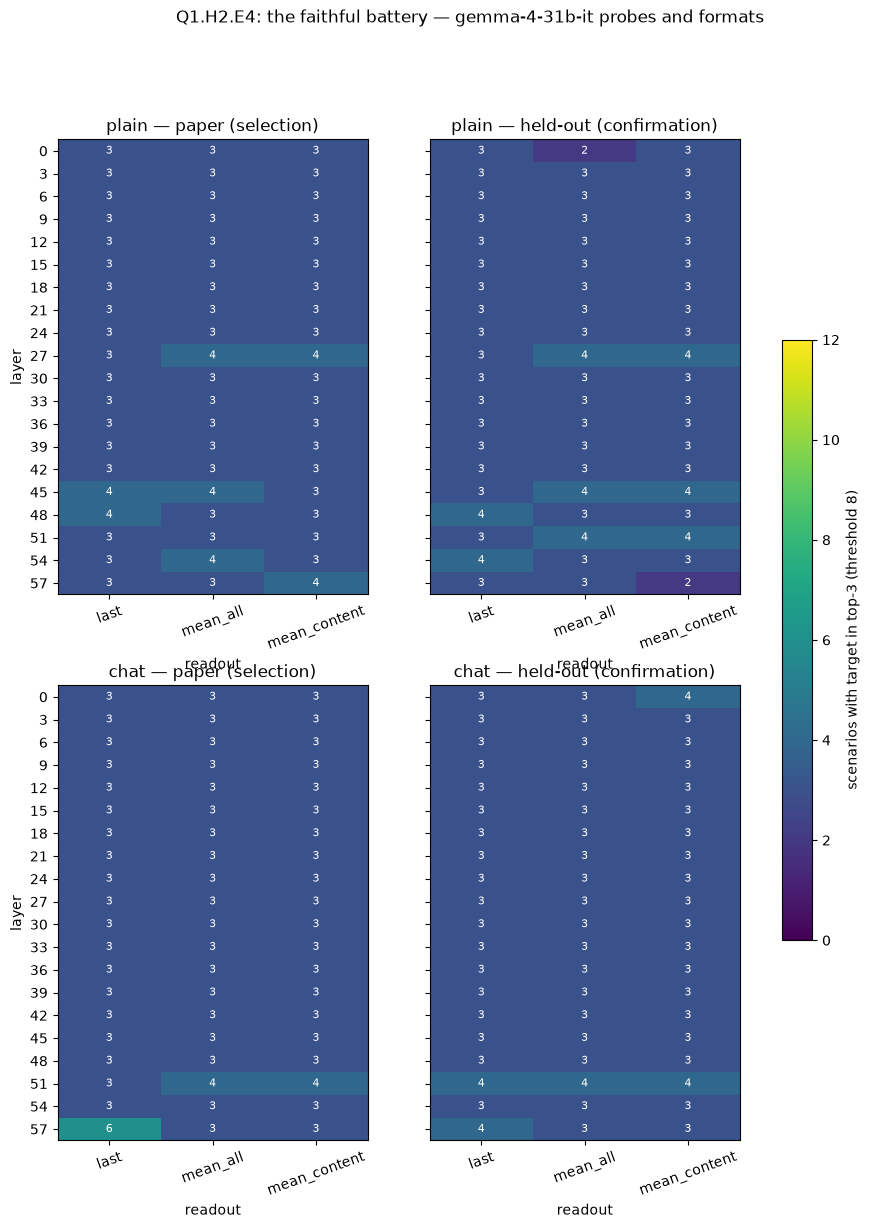

In [2]:
fig, axes = plt.subplots(len(formats), 2, figsize=(11, 6.5 * len(formats)), sharey=True, squeeze=False)
for fi, fmt in enumerate(formats):
    for ki, kind in enumerate(("scenario", "heldout")):
        ax = axes[fi][ki]
        G = grids[(fmt, kind)]
        im = ax.imshow(G, cmap="viridis", vmin=0, vmax=12, aspect="auto")
        for lp in range(len(layers)):
            for rp in range(len(READOUTS)):
                v = G[lp, rp]
                ax.text(rp, lp, str(v), ha="center", va="center", fontsize=8,
                        color="white" if v < 7 else "black",
                        fontweight="bold" if v >= 8 else "normal")
        ax.set_xticks(range(3)); ax.set_xticklabels(READOUTS, rotation=20)
        ax.set_title(f"{fmt} — {'paper (selection)' if kind == 'scenario' else 'held-out (confirmation)'}")
        ax.set_xlabel("readout")
    axes[fi][0].set_yticks(range(len(layers))); axes[fi][0].set_yticklabels(layers)
    axes[fi][0].set_ylabel("layer")
fig.colorbar(im, ax=axes, label="scenarios with target in top-3 (threshold 8)", shrink=0.6)
fig.suptitle("Q1.H2.E4: the faithful battery — gemma-4-31b-it probes and formats")
plt.show()

In [3]:
flat = [(grids[(f, "scenario")][lp, rp], grids[(f, "heldout")][lp, rp], f, layers[lp], r)
        for f in formats for lp in range(len(layers)) for rp, r in enumerate(READOUTS)]
flat.sort(reverse=True)
print("top combinations (paper, heldout, format, layer, readout):")
for row in flat[:10]:
    print(f"  paper {row[0]:2d}/12  heldout {row[1]:2d}/12  {row[2]:5s}  layer {row[3]:2d}  {row[4]}")
confirmed = [row for row in flat if row[0] >= 8 and row[1] >= 8]
print(f"\nregistered rule — combinations passing BOTH batteries at >=8/12: "
      f"{confirmed if confirmed else 'NONE'}")

top combinations (paper, heldout, format, layer, readout):
  paper  6/12  heldout  4/12  chat   layer 57  last
  paper  4/12  heldout  4/12  plain  layer 48  last
  paper  4/12  heldout  4/12  plain  layer 45  mean_all
  paper  4/12  heldout  4/12  plain  layer 27  mean_content
  paper  4/12  heldout  4/12  plain  layer 27  mean_all
  paper  4/12  heldout  4/12  chat   layer 51  mean_content
  paper  4/12  heldout  4/12  chat   layer 51  mean_all
  paper  4/12  heldout  3/12  plain  layer 54  mean_all
  paper  4/12  heldout  3/12  plain  layer 45  last
  paper  4/12  heldout  2/12  plain  layer 57  mean_content

registered rule — combinations passing BOTH batteries at >=8/12: NONE


## Reading

The verdict cell above is the registered test; TREE.md (Q1.H2.E4) records whatever it says.
E5's -it-native probes (self-generated stories and dialogues, 0-1% leakage) re-score this
battery in notebook 07.